# **Part A: Support Vector Machine for Perfectly Separable Classes(SVM)**

## 1. Introduction to Support Vector Machines (SVM)

Support Vector Machines (SVMs) classify data by finding an optimal hyperplane that maximizes the margin between different classes. In a binary classification problem, this hyperplane serves as the decision boundary.

The general equation of a hyperplane in an **n-dimensional space** is:

$$
\vec{w}^{\,T}\vec{x} + b = 0
$$

where $\vec{w}$ is the weight vector, $\vec{x}$ is a data point, and $b$ is the bias. The sign of $\vec{w}^{\,T}\vec{x} + b$ classifies the point.

For the 2-dimensional data (n=2) used in this notebook:
*   `w`: `(2,1)` - A 1-dimensional NumPy array (vector) representing the 2-dimensional weight vector of the hyperplane. It has `n=2` components.
*   `x`: `(2,1)` - A 1-dimensional NumPy array (vector) representing a 2-dimensional data point. It also has `n=2` components.
*   `b`: `()` - A scalar representing the bias term.

We'll use `numpy`, `pandas`, `matplotlib`, and `cvxpy`. The dataset is in Google Drive, so we'll mount it to access the data.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
# from google.colab import drive

# =====================================================
# Mount Google Drive
# =====================================================

# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 2. Loading the Dataset and Separating the Two Classes

Our dataset for this lab is stored as a CSV file (`svm_dataset.csv`) in Google Drive. You can access the file [here](https://drive.google.com/file/d/14r_0w0cN6DnUJgOlxWHjfgHYJjGYRh2h/view?usp=sharing).

This dataset contains two distinct classes, Class +1 and Class -1. These classes are often conceptualized as being generated from Gaussian distributions, where the mean vector defines the center and the covariance matrix describes the spread, potentially forming elliptical regions.

Understanding this helps visualize why data points form separable clusters. We will load it into a Pandas DataFrame and separate the points into NumPy arrays, `X1` and `X2`, for each class.

Mathematically, the points for each class are represented as matrices:

$$X_1 =
\begin{bmatrix}
x_{11} & y_{11}\\
x_{12} & y_{12}\\
\vdots & \vdots\\
x_{1N} & y_{1N}
\end{bmatrix}$$

and

$$X_2 =
\begin{bmatrix}
x_{21} & y_{21}\\
x_{22} & y_{22}\\
\vdots & \vdots\\
x_{2N} & y_{2N}
\end{bmatrix}$$

where each row represents a two-dimensional data point.

*   `X1`: `(N, 2)` - A matrix where `N` is the number of samples in Class +1 (120 in this dataset). Each row is a 2D point.
*   `X2`: `(N, 2)` - A matrix where `N` is the number of samples in Class -1 (120 in this dataset). Each row is a 2D point.

Separating the dataset into `X1` and `X2` simplifies the formulation of the Hard Margin SVM constraints. The upcoming code loads the dataset from Google Drive, displays the first few entries, extracts the two classes, and verifies the dimensions of the resulting matrices.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp
# from google.colab import drive

# =====================================================
# Mount Google Drive
# =====================================================

# drive.mount('/content/drive')
# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv(
    "/app/himshikhar26/data/svm_dataset.csv"
)

print(df.head())
# =====================================================
# Separate Classes
# =====================================================

# Class 1 points

X1 = df[['x1','y1']].values

# Class 2 points

X2 = df[['x2','y2']].values


print("Class +1 shape :", X1.shape)
print("Class -1 shape :", X2.shape)

         x1        y1        x2        y2
0 -5.827853 -2.673496  6.045465  1.939311
1 -7.122541 -1.071560  4.957850  4.419529
2 -4.426454 -1.999983  6.456854  1.242757
3 -8.371155 -2.861021  5.166328  1.815897
4 -4.469769 -0.926575  2.788683  5.502997
Class +1 shape : (120, 2)
Class -1 shape : (120, 2)


## 3. Problem Formulation

The Hard Margin SVM aims to find a hyperplane that perfectly separates two classes with the largest possible margin. The data points closest to this boundary are called **support vectors**.

We define two parallel hyperplanes for the margin:

**Positive Margin Hyperplane** (for Class +1 points):
$$
\vec{w}^{\,T}\vec{x} + b = 1
$$

**Negative Margin Hyperplane** (for Class -1 points):
$$
\vec{w}^{\,T}\vec{x} + b = -1
$$

This leads to the **Hard Margin Constraints**:

For $\vec{x}_i \in X_1$ (Class +1):
$$
\vec{w}^{\,T}\vec{x}_i + b \ge 1
$$

For $\vec{x}_j \in X_2$ (Class -1):
$$
\vec{w}^{\,T}\vec{x}_j + b \le -1
$$


These constraints ensure correct classification and separate the classes. The distance between these margin hyperplanes is $\frac{2}{||\vec{w}||_2}$. Maximizing this margin is achieved by minimizing $||\vec{w}||_2$. Thus, the **Optimization Objective** is:

$$\min ||\vec{w}||_2$$

Minimizing $||\vec{w}||_2$ maximizes the margin, resulting in the widest separation. This objective, combined with the hard margin constraints, forms a convex optimization problem.

In [2]:
# =====================================================
# Hard Margin SVM
# =====================================================

w = cp.Variable(2)
b = cp.Variable()


constraints = [
    X1 @ w + b >= 1,
    X2 @ w + b <= -1
]

objective = cp.Minimize(
    cp.norm(w,2)
)

problem = cp.Problem(
    objective,
    constraints
)


## 4. Convex Optimization Using CVXPY

Convex optimization finds global minima for convex functions over convex sets, making it reliable. The Hard Margin SVM is a convex optimization problem.

`CVXPY` is a Python library for convex optimization. It allows us to express our problem: defining `w` and `b` as variables, setting up constraints `X1 @ w + b >= 1` and `X2 @ w + b <= -1`, and the objective `cp.Minimize(cp.norm(w,2))`.

`problem.solve()` finds the optimal `w.value` and `b.value`. The **Margin Width** is then calculated as:

$$\text{Margin} = \frac{2}{||\vec{w}||}$$

This represents the maximum separation achieved.

In [3]:
problem.solve()

print("Optimal w =", w.value)
print("Optimal b =", b.value)

margin = 2 / np.linalg.norm(w.value)

print("Margin =", margin)

Optimal w = [-0.63516869 -0.62564579]
Optimal b = 1.5939735027520887
Margin = 2.243269329361996


## 5. Margin Maximization and Support Vectors

Margin maximization is key to SVMs; the optimal hyperplane maximizes the distance to the nearest training data points from each class, known as **Support Vectors**.

Support vectors lie exactly on the margin hyperplanes ($\vec{w}{\,^T}\vec{ x} + b = 1$ and $\vec{w}{\,^T}\vec{ x} + b = -1$). They are crucial as they determine the hyperplane's position. Removing a support vector would shift the optimal hyperplane.

The **Support Vector Conditions** are:

For positive class support vectors:
$$\vec{w}{\,^T} \vec{x}_i + b = 1$$


For negative class support vectors:
$$\vec{w}{\,^T} \vec{x}_i + b = -1$$

These points are identified in the code by checking which $w^T x + b$ values are close to 1 or -1.

*   `sv_pos`: `(k_pos,1)` - A 1-dimensional array of indices for positive class support vectors.
*   `sv_neg`: `(k_neg,1)` - A 1-dimensional array of indices for negative class support vectors.
*   `SV`: `(k_pos + k_neg, 2)` - A matrix containing the 2-dimensional coordinates of all support vectors. `(k_pos + k_neg)` is the total number of support vectors (e.g., 3 in the example run).

In [4]:
# =====================================================
# Support Vectors
# =====================================================

sv_pos = np.where(
    np.abs((X1 @ w.value + b.value) - 1) < 1e-3
)[0]

sv_neg = np.where(
    np.abs((X2 @ w.value + b.value) + 1) < 1e-3
)[0]

SV = np.vstack((
    X1[sv_pos],
    X2[sv_neg]
))

print(SV.shape)


print("Number of Support Vectors =", len(SV))

(3, 2)
Number of Support Vectors = 3


## 6. Visualization and Results

Visualizing the SVM solution helps confirm the optimal hyperplane. We will plot:
*   **Class +1** and **Class -1 points**.
*   **Support Vectors**, highlighted.
*   **Decision Line ($\vec{w}{\,^T} \vec{x} + b = 0$)**: The optimal separating hyperplane.
*   **Margin Plus Line ($\vec{w}{\,^T} \vec{x} + b = 1$)**: Borders Class +1.
*   **Margin Minus Line ($\vec{w}{\,^T} \vec{x} + b = 1$)**: Borders Class -1.


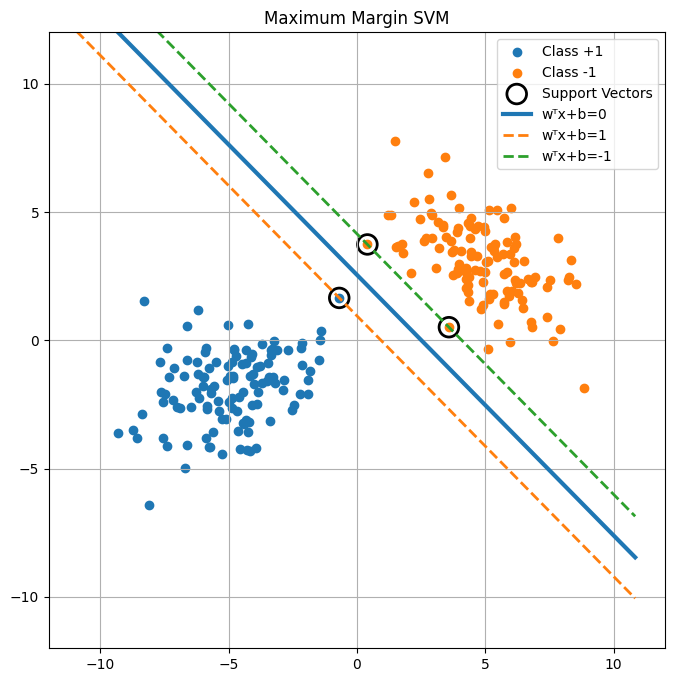

In [5]:
# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(10,8))

ax.scatter(
    X1[:,0],
    X1[:,1],
    label='Class +1'
)

ax.scatter(
    X2[:,0],
    X2[:,1],
    label='Class -1'
)

ax.scatter(
    SV[:,0],
    SV[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)
X = np.vstack((
    X1,
    X2
))
x = np.linspace(
    X[:,0].min()-2,
    X[:,0].max()+2,
    500
)

w1 = w.value[0]
w2 = w.value[1]

decision_line = -(w1*x + b.value)/w2

margin_plus = -(w1*x + b.value - 1)/w2

margin_minus = -(w1*x + b.value + 1)/w2

ax.plot(
    x,
    decision_line,
    linewidth=3,
    label='wᵀx+b=0'
)

ax.plot(
    x,
    margin_plus,
    '--',
    linewidth=2,
    label='wᵀx+b=1'
)

ax.plot(
    x,
    margin_minus,
    '--',
    linewidth=2,
    label='wᵀx+b=-1'
)

ax.set_aspect('equal')
ax.set_xlim(-12,12)

ax.set_ylim(-12,12)
ax.set_title(
    'Maximum Margin SVM'
)

ax.grid(True)
ax.legend()

plt.show()

## 7. Geometric Interpretation and Conclusion

This lab demonstrated the Hard Margin Support Vector Machine. We focused on finding an optimal hyperplane that maximizes the separation between two classes, effectively drawing the widest 'street' possible. The geometric interpretation highlights this maximum margin.

We formulated the problem using convex optimization:
*   **Hard Margin Constraints**: $X_1 \vec{w} + b \ge 1$ and $X_2 \vec{w} + b \le -1$.
*   **Optimization Objective**: Minimizing $||\vec{w}||_2$ to maximize the margin width, $\frac{2}{||\vec{w}||}$.

`CVXPY` helped us find the optimal $w$ and $b$. The **Support Vectors** ($\vec{w}{\,^T} \vec{x} + b = 1$ or $\vec{w}{\,^T} \vec{x} + b = -1$) are the critical points on the margin boundaries, solely influencing the hyperplane. This makes SVMs robust.

The visualization provided a clear understanding of the SVM's solution, reinforcing the geometric intuition behind maximum margin classification. The Hard Margin SVM is a powerful classifier for linearly separable data, offering a robust decision boundary defined by its support vectors.

## **Practice Question:** Create Your Own Linearly Separable Dataset

Now it's your turn! Create a new synthetic dataset that consists of two linearly separable classes. You can use NumPy's random number generation functions to generate data points for `X1` (Class +1) and `X2` (Class -1).

**Task:**

1.  **Generate Data:** Create two sets of 2D data points, `X1` and `X2`, ensuring they are linearly separable. You can use a similar approach to the following snippet. Modify the means (`mu1`, `mu2`) and standard deviations (`sigma1`, `sigma2`) to create different distributions.

    **Hints for Data Generation:**
    *   Define `N` for the number of samples per class.
    *   For Class +1, choose a mean vector (e.g., `mu1 = np.array([-5, -2])`) and a standard deviation (e.g., `sigma1 = 2.0`). Calculate the covariance matrix, `cov1`, as `sigma1**2 * np.eye(2)` for circular clusters.
    *   Similarly, for Class -1, choose a different mean vector (e.g., `mu2 = np.array([5, 3])`) and standard deviation (`sigma2`).
    *   Use `np.random.multivariate_normal(mean, covariance, N)` to generate `X1` and `X2`. Remember to set `np.random.seed()` for reproducibility.
    *   Ensure your `mu1` and `mu2` are sufficiently far apart to guarantee linear separability.

2.  **Apply SVM:** After generating your `X1` and `X2` arrays, adapt and use the Hard Margin SVM code provided in this notebook (from Section 3 onwards) to find the optimal `w` and `b` for *your new dataset*.


3.  **Visualize Results:** Plot your generated data, the decision boundary, the margin lines, and highlight the support vectors, similar to the visualization in Section 6. Observe how the SVM adapts to your custom data.


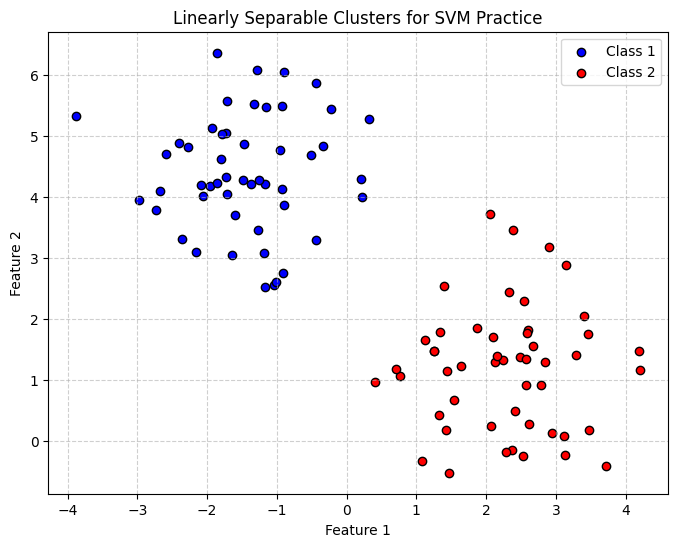

In [15]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2 distinct clusters
# n_samples: total points, centers=2: two clusters, cluster_std: tightness of clusters
X, y = make_blobs(
    n_samples=100, centers=2, cluster_std=1.0, random_state=42, center_box=(-5.0, 5.0)
)

C1 = X[y == 0]
C2 = X[y == 1]

# To guarantee absolute zero overlap, we can manually shift the clusters further apart
# Let's shift the points belonging to cluster 1
# X[y == 1] += [5, 5]

# Plotting the dataset
plt.figure(figsize=(8, 6))
plt.scatter(C1[:,0], C1[:,1], color="blue", label="Class 1", edgecolors="k")
plt.scatter(C2[:,0], C2[:,1], color="red", label="Class 2", edgecolors="k")

plt.title("Linearly Separable Clusters for SVM Practice")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [18]:
# =====================================================
# Hard Margin SVM
# =====================================================

w = cp.Variable(2)
b = cp.Variable()


constraints = [
    C1 @ w + b >= 1,
    C2 @ w + b <= -1
]

objective = cp.Minimize(
    cp.norm(w,2)
)

problem = cp.Problem(
    objective,
    constraints
)

problem.solve()

print("Optimal w =", w.value)
print("Optimal b =", b.value)

margin = 2 / np.linalg.norm(w.value)

print("Margin =", margin)

# =====================================================
# Support Vectors
# =====================================================

sv_pos = np.where(
    np.abs((C1 @ w.value + b.value) - 1) < 1e-3
)[0]

sv_neg = np.where(
    np.abs((C2 @ w.value + b.value) + 1) < 1e-3
)[0]

SV = np.vstack((
    C1[sv_pos],
    C2[sv_neg]
))

print(SV.shape)


print("Number of Support Vectors =", len(SV))

Optimal w = [-0.99905805  0.60165526]
Optimal b = -1.1768414216103165
Margin = 1.7149189930937108
(3, 2)
Number of Support Vectors = 3


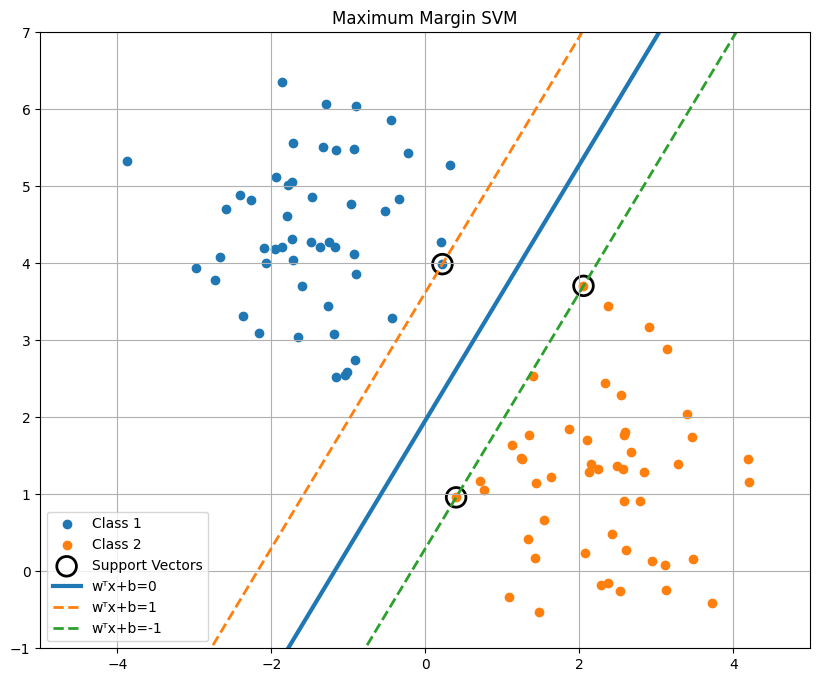

In [24]:
# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(figsize=(10,8))

ax.scatter(
    C1[:,0],
    C1[:,1],
    label='Class 1'
)

ax.scatter(
    C2[:,0],
    C2[:,1],
    label='Class 2'
)

ax.scatter(
    SV[:,0],
    SV[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)
C = np.vstack((
    C1,
    C2
))
x = np.linspace(
    C[:,0].min()-2,
    C[:,0].max()+2,
    500
)

w1 = w.value[0]
w2 = w.value[1]

decision_line = -(w1*x + b.value)/w2

margin_plus = -(w1*x + b.value - 1)/w2

margin_minus = -(w1*x + b.value + 1)/w2

ax.plot(
    x,
    decision_line,
    linewidth=3,
    label='wᵀx+b=0'
)

ax.plot(
    x,
    margin_plus,
    '--',
    linewidth=2,
    label='wᵀx+b=1'
)

ax.plot(
    x,
    margin_minus,
    '--',
    linewidth=2,
    label='wᵀx+b=-1'
)

ax.set_aspect('equal')
ax.set_xlim(-5,5)

ax.set_ylim(-1,7)
ax.set_title(
    'Maximum Margin SVM'
)

ax.grid(True)
ax.legend()

plt.show()

# **Part B: Soft Margin SVM for Intersecting Regions**

## 1. Motivation for Soft Margin SVM

Part A covered Hard Margin SVM for perfectly separable datasets. However, real-world data often has noise or overlapping classes, making a perfect linear separation impossible.

Applying Hard Margin SVM to overlapping data results in an **infeasible optimization problem**.

**Soft Margin SVM** addresses this by tolerating some misclassifications or margin violations. It balances maximizing the margin with minimizing classification errors, making it suitable for non-linearly separable data.

## 2. Loading the Dataset and Separating the Two Classes

To demonstrate Soft Margin SVM, we will use a synthetic dataset where classes are *not* linearly separable; they overlap. This dataset is stored as a CSV file (`soft_margin_dataset.csv`) in Google Drive. You can access the file [here](https://drive.google.com/file/d/1r2EeVlLhA2n2tRrmynd2IS82DXlpM58B/view?usp=sharing).

As in Part A, Gaussian distributions are defined by a mean vector (center) and a covariance matrix (spread/orientation). For this dataset, `mu` (mean) and `cov` (covariance) values were chosen such that the Class +1 and Class -1 data points intersect, simulating a more challenging classification scenario.

We will load it into a Pandas DataFrame and separate the points into NumPy arrays, `X1` and `X2`, for each class. This simplifies the formulation of the Soft Margin SVM constraints.

*   `X1`: `(N, 2)` - A matrix where `N` is the number of samples in Class +1 (120 in this dataset). Each row is a 2D point.
*   `X2`: `(N, 2)` - A matrix where `N` is the number of samples in Class -1 (120 in this dataset). Each row is a 2D point.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cvxpy as cp

# =====================================================
# Load Dataset
# =====================================================

df = pd.read_csv(
    "/app/himshikhar26/data/soft_margin_dataset.csv"
)

print(df.head())

# =====================================================
# Separate Classes
# =====================================================

X1 = df[['x1','y1']].values

X2 = df[['x2','y2']].values

print("Class +1 shape :", X1.shape)
print("Class -1 shape :", X2.shape)

         x1        y1        x2        y2
0 -2.796329 -0.810054  3.350311 -0.104740
1 -4.417987  0.857850  1.791746  2.682159
2 -1.382174  0.045505  3.912845 -0.871523
3 -5.509421 -1.219021  2.328264 -0.383488
4 -1.580946  1.228481 -0.885101  3.645334
Class +1 shape : (120, 2)
Class -1 shape : (120, 2)


## 3. Failure of Hard Margin SVM for Overlapping Classes

Recall Part A's **Hard Margin Constraints**:

For $\vec{x}_i \in X_1$ (Class +1):
$$X_1 \vec{w} + b \ge 1$$

For $\vec{x}_j \in X_2$ (Class -1):
$$X_2\vec{w} + b \le -1$$

These require all points to be outside the margin on their correct sides. When classes overlap, some points from one class will inevitably fall into the region of the other. For example, a Class +1 point might have $\vec{w}{\,^T}\vec{x} + b < 1$, violating its constraint.

If such violations occur, the Hard Margin SVM optimization problem becomes **infeasible**, meaning no solution for $w$ and $b$ can satisfy all strict conditions. This shows why Hard Margin SVM fails for overlapping classes; it needs a more flexible approach.

## 4. Soft Margin Formulation Using Slack Variables

To handle overlapping classes, **Soft Margin SVM** introduces **slack variables** ($\xi$). These variables quantify how much a data point violates the margin constraints.

For each data point $\vec{x}_i$, we have a slack variable $\xi_i \ge 0$. The **Soft Margin Constraints** relax the hard margin:

For points $\vec{x}_i$ in Class +1:
$$X_1 \vec{w} + b \ge 1 - \xi^{(1)}$$

For points $\vec{x}_j$ in Class -1:
$$X_2 \vec{w} + b \le -1 + \xi^{(2)}$$



**Geometric meaning of violations:**
*   $\xi_i = 0$: Point correctly classified, on/beyond the margin.
*   $0 < \xi_i < 1$: Point within the margin but correctly classified.
*   $\xi_i \ge 1$: Point misclassified (on the wrong side of the decision boundary).

The **Soft Margin Objective** balances margin maximization (minimizing $||\vec{w}||_2$) and minimizing total slack, using a penalty parameter $C > 0$:

$$\min \left( ||\vec{w}||_2 + C\sum_i \xi_i^{(1)} + C\sum_j \xi_j^{(2)} \right)$$

$C$ controls the trade-off:
*   Small $C$: Wider margin, more training errors (higher bias, lower variance).
*   Large $C$: Fewer training errors, narrower margin, higher risk of overfitting (lower bias, higher variance).

This is a convex optimization problem, solved by setting up `w`, `b`, `xi1`, `xi2`, constraints, and objective.

In [26]:
# =====================================================
# Soft Margin SVM
# =====================================================

N1 = len(X1)
N2 = len(X2)

C = 1.0
# Penalty parameter

w = cp.Variable(2)
b = cp.Variable()

# Slack variables
xi1 = cp.Variable(N1)
xi2 = cp.Variable(N2)

constraints = [

    X1 @ w + b >= 1 - xi1,

    X2 @ w + b <= -1 + xi2,

    xi1 >= 0,

    xi2 >= 0
]

objective = cp.Minimize(

    cp.norm(w,2)

    +

    C * cp.sum(xi1)

    +

    C * cp.sum(xi2)

)

problem = cp.Problem(
    objective,
    constraints
)

Here,
*   `N1`: `()` - Scalar, number of samples in Class +1 (120).
*   `N2`: `()` - Scalar, number of samples in Class -1 (120).
*   `xi1`: `(N1,)` - A 1-dimensional NumPy array (vector) of slack variables for each Class +1 sample.
*   `xi2`: `(N2,)` - A 1-dimensional NumPy array (vector) of slack variables for each Class -1 sample.

## 5. Convex Optimization Using CVXPY

Like Hard Margin SVM, Soft Margin SVM is a convex optimization problem, ensuring a global optimum. `CVXPY` simplifies solving this.

After defining `w`, `b`, and slack variables `xi1`, `xi2`, along with the constraints and objective from Section 4, we use `problem.solve()`. `CVXPY` then finds the optimal values for `w`, `b`, `xi1`, and `xi2`.

The optimal values are accessed via `.value`. The **Margin Width** for Soft Margin SVM is still defined as:

$$\text{Margin} = \frac{2}{||\vec{w}||_2}$$

This reflects the separation between the boundaries, even if points violate them. Minimizing $||w||_2$ still aims for a wider geometric margin.

In [27]:
problem.solve()

print("Optimal w =", w.value)

print("Optimal b =", b.value)

margin = 2 / np.linalg.norm(
    w.value
)

print("Margin =", margin)

Optimal w = [-0.75686608 -0.39630526]
Optimal b = 0.19389577488089388
Margin = 2.340976667244213


## 6. Support Vectors, Margin Violations, and Results

In Soft Margin SVM, **support vectors** are points closest to the decision boundary or those violating the margin. They still define the margin, but their conditions are relaxed due to slack variables. Support vectors have $\vec{w}{\,^T}\vec{x} + b$ values approximately 1 (Class +1) or -1 (Class -1), meaning they are on or near the margin boundaries.

**Support Vector Conditions (approximate for Soft Margin):**

For positive class support vectors:
$$\vec{w}{\,^T} \vec{x} + b \approx 1$$

For negative class support vectors:
$$\vec{w}{\,^T} \vec{x} + b \approx -1$$

Support vectors can be:
*   On the margin ($\xi = 0$).
*   Within the margin but correctly classified ($0 < \xi < 1$).
*   Misclassified ($\xi \ge 1$).

The code identifies support vectors using a `1e-2` tolerance for numerical precision. These points are critical for defining the optimal hyperplane in overlapping scenarios. The `Optimal w` and `Optimal b` define the classifier, and the `Margin` indicates separation. Soft Margin SVM often has more support vectors, as points within the margin or misclassified can be critical.

In [28]:
# =====================================================
# Support Vectors
# =====================================================

sv_pos = np.where(

    np.abs(
        (X1 @ w.value + b.value) - 1
    ) < 1e-2 # Using a small tolerance to find points near the margin

)[0]

sv_neg = np.where(

    np.abs(
        (X2 @ w.value + b.value) + 1
    ) < 1e-2 # Using a small tolerance to find points near the margin

)[0]

SV = np.vstack((

    X1[sv_pos],

    X2[sv_neg]

))

print(
    "Number of Support Vectors =",
    len(SV)
)

Number of Support Vectors = 5


## 7. Geometric Interpretation and Conclusion

The visualization for Soft Margin SVM offers a crucial geometric understanding. We will plot:
*   Original Class +1 and Class -1 data points.
*   Highlighted Support Vectors.
*   **Decision Line ($\vec{w}{\,^T} \vec{x} + b = 0$)**: The optimal hyperplane balancing margin and errors.
*   **Margin Plus Line ($\vec{w}{\,^T} \vec{x} + b = 1$)** and **Margin Minus Line ($\vec{w}{\,^T} \vec{x} + b = -1$)**: Defining the margin region.

You'll see points from both classes *within* the margin or *misclassified*. These are the margin violations enabled by slack variables ($\xi$). The penalty parameter $C$ controls how severely these violations are penalized.

Plotting equations for lines are the same as in Hard Margin SVM. The key difference is that $w$ and $b$ are optimized to allow errors. This highlights how Soft Margin SVM finds a robust compromise for separating overlapping classes, making it practical for real-world datasets.

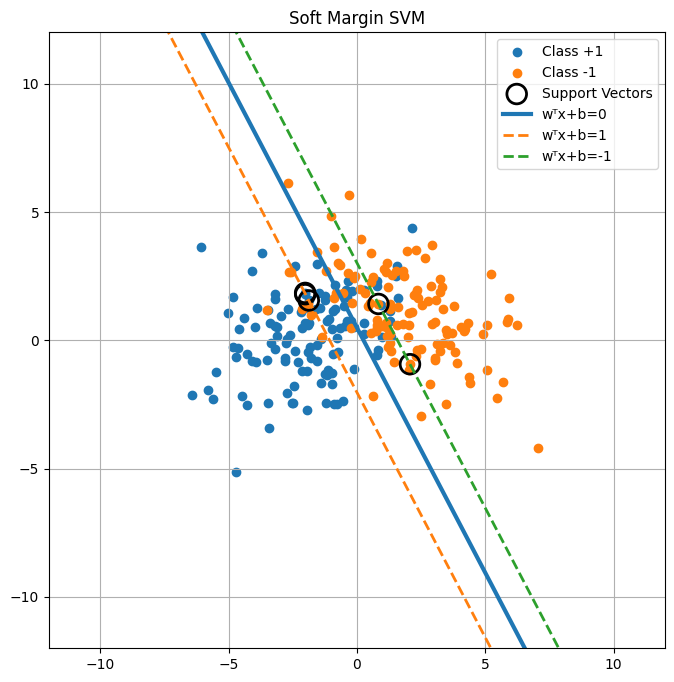

========== Soft Margin SVM Analysis ==========

Class +1 Points            : 120
Correct Outside Margin     : 75
Inside Margin              : 23
Misclassified              : 22

Class -1 Points            : 120
Correct Outside Margin     : 74
Inside Margin              : 32
Misclassified              : 14

Total Misclassified Points : 36


In [29]:
# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(
    figsize=(10,8)
)

ax.scatter(
    X1[:,0],
    X1[:,1],
    label='Class +1'
)

ax.scatter(
    X2[:,0],
    X2[:,1],
    label='Class -1'
)

ax.scatter(
    SV[:,0],
    SV[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

# =====================================================
# Create x-range
# =====================================================

X = np.vstack((X1,X2))

x = np.linspace(

    X[:,0].min()-2,

    X[:,0].max()+2,

    500
)

# =====================================================
# Decision Boundary
# =====================================================

w1 = w.value[0]

w2 = w.value[1]

decision_line = -(
    w1*x + b.value
)/w2

margin_plus = -(
    w1*x + b.value - 1
)/w2

margin_minus = -(
    w1*x + b.value + 1
)/w2

ax.plot(
    x,
    decision_line,
    linewidth=3,
    label='wᵀx+b=0'
)

ax.plot(
    x,
    margin_plus,
    '--',
    linewidth=2,
    label='wᵀx+b=1'
)

ax.plot(
    x,
    margin_minus,
    '--',
    linewidth=2,
    label='wᵀx+b=-1'
)

ax.set_aspect('equal')
ax.set_xlim(-12,12)

ax.set_ylim(-12,12)
ax.set_title(
    'Soft Margin SVM'
)

ax.grid(True)

ax.legend()

plt.show()

# =====================================================
# Classification Analysis
# =====================================================

# Decision function values
score1 = X1 @ w.value + b.value     # Class +1
score2 = X2 @ w.value + b.value     # Class -1

# -----------------------------------------------------
# Misclassified Points
# -----------------------------------------------------

# Class +1 should satisfy wᵀx+b > 0
mis1 = score1 <= 0

# Class -1 should satisfy wᵀx+b < 0
mis2 = score2 >= 0

# -----------------------------------------------------
# Correctly Classified but Inside Margin
# -----------------------------------------------------

inside1 = (score1 > 0) & (score1 < 1)
inside2 = (score2 < 0) & (score2 > -1)

# -----------------------------------------------------
# Correctly Classified Outside Margin
# -----------------------------------------------------

correct1 = score1 >= 1
correct2 = score2 <= -1

# -----------------------------------------------------
# Print Results
# -----------------------------------------------------

print("========== Soft Margin SVM Analysis ==========\n")

print(f"Class +1 Points            : {len(X1)}")
print(f"Correct Outside Margin     : {np.sum(correct1)}")
print(f"Inside Margin              : {np.sum(inside1)}")
print(f"Misclassified              : {np.sum(mis1)}\n")

print(f"Class -1 Points            : {len(X2)}")
print(f"Correct Outside Margin     : {np.sum(correct2)}")
print(f"Inside Margin              : {np.sum(inside2)}")
print(f"Misclassified              : {np.sum(mis2)}\n")
print(f"Total Misclassified Points : {np.sum(mis1)+np.sum(mis2)}")



## **Practice Question: Soft Margin SVM with Overlapping Data**

Now it's your turn to create a new synthetic dataset where the classes are *not* linearly separable, and then apply the Soft Margin SVM.

**Task:**

1.  **Generate Overlapping Data:** Create two sets of 2D data points, `X1` (Class +1) and `X2` (Class -1), ensuring they are *not* linearly separable (i.e., they overlap). You can use `np.random.multivariate_normal` similar to the dataset generation in Part A, but carefully choose your means (`mu1`, `mu2`) and standard deviations (`sigma1`, `sigma2`) and potentially the covariance matrices so that the distributions intersect significantly. Experiment with overlapping regions.

    **Hints for Data Generation:**
    *   Define `N` for the number of samples per class.
    *   Choose mean vectors (`mu1`, `mu2`) that are close to each other, or with large standard deviations (`sigma1`, `sigma2`), to create overlap.
    *   For circular clusters, `cov = sigma**2 * np.eye(2)`.
    *   Use `np.random.multivariate_normal(mean, covariance, N)` to generate `X1` and `X2`. Remember to set `np.random.seed()` for reproducibility.
    *   Consider adding some outliers to one or both classes to further test the Soft Margin SVM's robustness.

2.  **Apply Soft Margin SVM:** After generating your `X1` and `X2` arrays, adapt and use the Soft Margin SVM code provided in this notebook (from Section 4 onwards) to find the optimal `w` and `b` for *your new overlapping dataset*. Experiment with different values of the penalty parameter `C` (e.g., `C=0.1`, `C=1.0`, `C=10.0`) to observe its effect on the margin and misclassifications.

3.  **Visualize Results:** Plot your generated data, the decision boundary, the margin lines, and highlight the support vectors, similar to the visualization in Section 7 of Part B. Clearly indicate which points are misclassified or fall within the margin. Comment on how changing `C` affects the outcome.

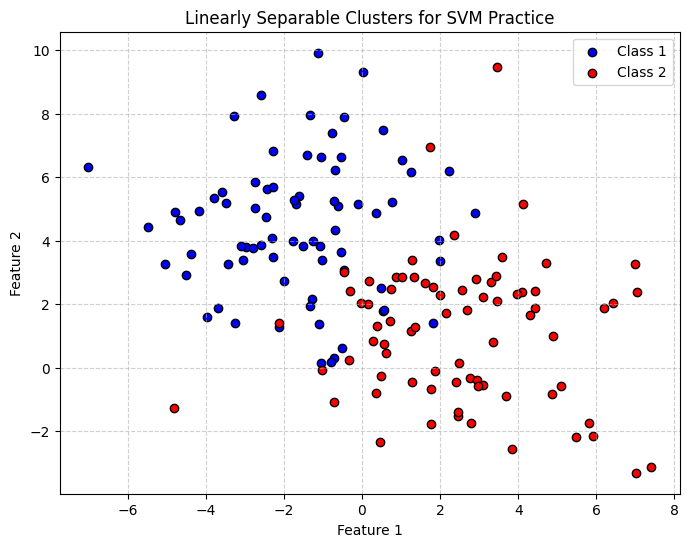

In [32]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# Generate 2 distinct clusters
# n_samples: total points, centers=2: two clusters, cluster_std: tightness of clusters
# X, y = make_blobs(
#     n_samples=100, centers=2, cluster_std=1.0, random_state=42, center_box=(-5.0, 5.0)
# )
X, y = make_blobs(
    n_samples=150, centers=2, cluster_std=2.2, random_state=42, center_box=(-5.0, 5.0)
)

C1 = X[y == 0]
C2 = X[y == 1]

# To guarantee absolute zero overlap, we can manually shift the clusters further apart
# Let's shift the points belonging to cluster 1
# X[y == 1] += [5, 5]

# Plotting the dataset
plt.figure(figsize=(8, 6))
plt.scatter(C1[:,0], C1[:,1], color="blue", label="Class 1", edgecolors="k")
plt.scatter(C2[:,0], C2[:,1], color="red", label="Class 2", edgecolors="k")

plt.title("Linearly Separable Clusters for SVM Practice")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [34]:
# =====================================================
# Soft Margin SVM
# =====================================================

N1 = len(C1)
N2 = len(C2)

C = 1.0
# Penalty parameter

w = cp.Variable(2)
b = cp.Variable()

# Slack variables
xi1 = cp.Variable(N1)
xi2 = cp.Variable(N2)

constraints = [
    C1 @ w + b >= 1 - xi1,
    C2 @ w + b <= -1 + xi2,
    xi1 >= 0,
    xi2 >= 0
]

objective = cp.Minimize(
    cp.norm(w,2)
    +
    C * cp.sum(xi1)
    +
    C * cp.sum(xi2)
)

problem = cp.Problem(
    objective,
    constraints
)

problem.solve()

print("Optimal w =", w.value)
print("Optimal b =", b.value)

margin = 2 / np.linalg.norm(
    w.value
)
print("Margin =", margin)

# =====================================================
# Support Vectors
# =====================================================

sv_pos = np.where(

    np.abs(
        (C1 @ w.value + b.value) - 1
    ) < 1e-2 # Using a small tolerance to find points near the margin

)[0]

sv_neg = np.where(

    np.abs(
        (C2 @ w.value + b.value) + 1
    ) < 1e-2 # Using a small tolerance to find points near the margin

)[0]

SV = np.vstack((
    C1[sv_pos],
    C2[sv_neg]
))

print(
    "Number of Support Vectors =",
    len(SV)
)

Optimal w = [-0.70381822  0.50680348]
Optimal b = -1.2360793639719163
Margin = 2.3060062767178944
Number of Support Vectors = 4


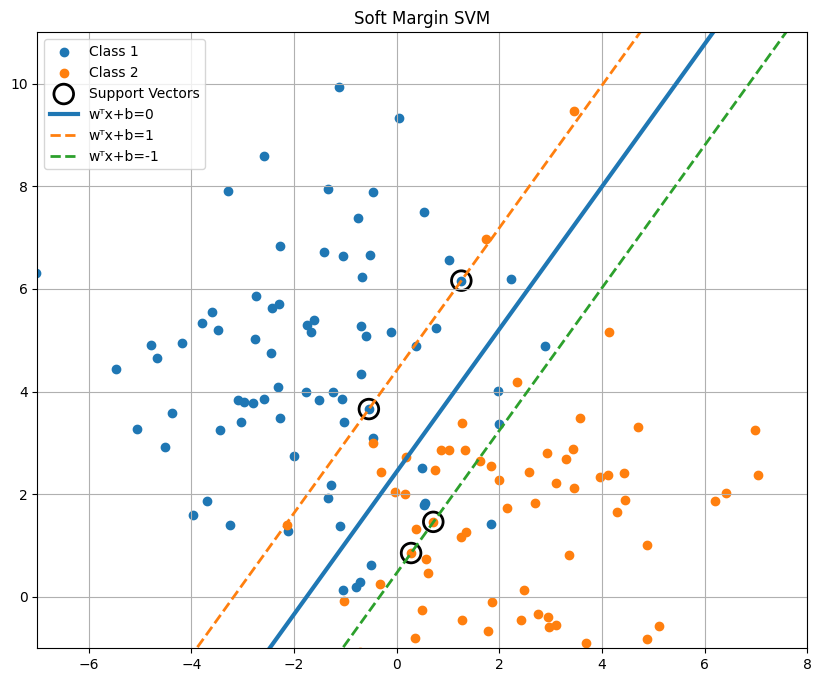

========== Soft Margin SVM Analysis ==========

Class 1 Points            : 75
Correct Outside Margin     : 55
Inside Margin              : 9
Misclassified              : 11

Class 2 Points            : 75
Correct Outside Margin     : 55
Inside Margin              : 13
Misclassified              : 7

Total Misclassified Points : 18


In [36]:
# =====================================================
# Plot
# =====================================================

fig, ax = plt.subplots(
    figsize=(10,8)
)

ax.scatter(
    C1[:,0],
    C1[:,1],
    label='Class 1'
)

ax.scatter(
    C2[:,0],
    C2[:,1],
    label='Class 2'
)

ax.scatter(
    SV[:,0],
    SV[:,1],
    s=200,
    facecolors='none',
    edgecolors='black',
    linewidths=2,
    label='Support Vectors'
)

# =====================================================
# Create x-range
# =====================================================

C = np.vstack((C1,C2))

x = np.linspace(
    C[:,0].min()-2,
    C[:,0].max()+2,
    500
)

# =====================================================
# Decision Boundary
# =====================================================

w1 = w.value[0]
w2 = w.value[1]

decision_line = -(
    w1*x + b.value
)/w2

margin_plus = -(
    w1*x + b.value - 1
)/w2

margin_minus = -(
    w1*x + b.value + 1
)/w2

ax.plot(
    x,
    decision_line,
    linewidth=3,
    label='wᵀx+b=0'
)

ax.plot(
    x,
    margin_plus,
    '--',
    linewidth=2,
    label='wᵀx+b=1'
)

ax.plot(
    x,
    margin_minus,
    '--',
    linewidth=2,
    label='wᵀx+b=-1'
)

ax.set_aspect('equal')
ax.set_xlim(-7,8)

ax.set_ylim(-1,11)
ax.set_title(
    'Soft Margin SVM'
)

ax.grid(True)
ax.legend()
plt.show()

# =====================================================
# Classification Analysis
# =====================================================

# Decision function values
score1 = C1 @ w.value + b.value     # Class +1
score2 = C2 @ w.value + b.value     # Class -1

# -----------------------------------------------------
# Misclassified Points
# -----------------------------------------------------

# Class +1 should satisfy wᵀx+b > 0
mis1 = score1 <= 0

# Class -1 should satisfy wᵀx+b < 0
mis2 = score2 >= 0

# -----------------------------------------------------
# Correctly Classified but Inside Margin
# -----------------------------------------------------

inside1 = (score1 > 0) & (score1 < 1)
inside2 = (score2 < 0) & (score2 > -1)

# -----------------------------------------------------
# Correctly Classified Outside Margin
# -----------------------------------------------------

correct1 = score1 >= 1
correct2 = score2 <= -1

# -----------------------------------------------------
# Print Results
# -----------------------------------------------------

print("========== Soft Margin SVM Analysis ==========\n")

print(f"Class 1 Points            : {len(C1)}")
print(f"Correct Outside Margin     : {np.sum(correct1)}")
print(f"Inside Margin              : {np.sum(inside1)}")
print(f"Misclassified              : {np.sum(mis1)}\n")

print(f"Class 2 Points            : {len(C2)}")
print(f"Correct Outside Margin     : {np.sum(correct2)}")
print(f"Inside Margin              : {np.sum(inside2)}")
print(f"Misclassified              : {np.sum(mis2)}\n")
print(f"Total Misclassified Points : {np.sum(mis1)+np.sum(mis2)}")